# VideoPainter notebook demo

This notebook mirrors the main Gradio workflow without starting a web UI:

1. Configure paths and inference options.
2. Validate the environment and input video.
3. Decode the video at up to 8 FPS, keep at most 49 frames, and resize to 720×480.
4. Enter SAM2 prompts manually as `(x, y, label)` tuples (`1` = positive, `0` = negative).
5. Preview clicks, segment the selected frame, and track the mask through the video.
6. Release SAM2 memory, load the VideoPainter pipelines, and run inpainting.

Run one cell at a time. The expensive models are loaded only in their dedicated cells, which makes failures easier to isolate.

In [1]:
# 1. Imports and project paths
import gc
import importlib.util
import json
import os
import sys
from pathlib import Path

import cv2
import imageio
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage
import torch
from decord import VideoReader
from IPython.display import Video, display
from PIL import Image

cwd = Path.cwd().resolve()
if (cwd / "app" / "utils.py").is_file():
    PROJECT_ROOT = cwd
elif (cwd / "utils.py").is_file() and cwd.name == "app":
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Launch this notebook from the VideoPainter project root or its app/ directory.")

APP_DIR = PROJECT_ROOT / "app"
if str(APP_DIR) not in sys.path:
    sys.path.insert(0, str(APP_DIR))

# SAM2's Hydra config lookup and app/utils.py use paths relative to app/.
os.chdir(APP_DIR)
OUTPUT_DIR = APP_DIR / "notebook_outputs"
print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {Path.cwd()}")


Project root: /workspace/VideoPainter
Working directory: /workspace/VideoPainter/app


## Configuration

`PROMPT_FRAME` uses zero-based indexing after video resampling. `TRACK_START_FRAME` and `TRACK_END_FRAME` are inclusive. Set `TRACK_END_FRAME = None` to use the final loaded frame.

`CPU_OFFLOAD_MODE` may be `"auto"`, `"on"`, or `"off"`. Auto mode enables Diffusers CPU offloading when free GPU memory is below `AUTO_OFFLOAD_MIN_FREE_GIB`.

In [18]:
# 2. User configuration
VIDEO_PATH = PROJECT_ROOT / "app/assets/yuewen_jobs.mp4"

SAM2_CHECKPOINT = PROJECT_ROOT / "ckpt/sam2_hiera_large.pt"
SAM2_MODEL_CONFIG = "sam2_hiera_l.yaml"
VIDEO_MODEL_PATH = PROJECT_ROOT / "ckpt/CogVideoX-5b-I2V"
INPAINTING_BRANCH_PATH = PROJECT_ROOT / "ckpt/VideoPainter/VideoPainter/checkpoints/branch"
ID_ADAPTER_PATH = PROJECT_ROOT / "ckpt/VideoPainter/VideoPainterID/checkpoints"
IMAGE_INPAINTING_MODEL_PATH = PROJECT_ROOT / "ckpt/flux_inp"

VIDEO_CAPTION = "Jobs spoke at the press conference wearing a black shirt."
TARGET_REGION_CAPTION = "Blood on face"

PROMPT_FRAME = 0
TRACK_START_FRAME = 0
TRACK_END_FRAME = None

# Each item is (x, y, label): label 1 includes a region; label 0 excludes it.
CLICKS = [
    (189, 328, 0),
    (279, 167, 1),
]

SEED = 42
CFG_SCALE = 6.0
DILATE_SIZE = 16
CPU_OFFLOAD_MODE = "on"  # "auto", "on", or "off"
AUTO_OFFLOAD_MIN_FREE_GIB = 44.0
SAM2_OFFLOAD_VIDEO_TO_CPU = True
SAM2_OFFLOAD_STATE_TO_CPU = True
SAVE_SAM2_CACHE = True
LOAD_SAM2_CACHE = True
# Set to None to use notebook_outputs/<video_stem>_sam2_masks.npz.
SAM2_CACHE_PATH = None

SAVE_FLUX_CACHE = True
LOAD_FLUX_CACHE = True
# Set either path to None to use notebook_outputs/<video_stem>_flux_* defaults.
FLUX_FRAME_CACHE_PATH = None
FLUX_MASKS_CACHE_PATH = None

SAVE_VIDEO_FRAME_CACHE = True
LOAD_VIDEO_FRAME_CACHE = True
# Set to None to use notebook_outputs/<video_stem>_videopainter_frames/.
VIDEO_FRAME_CACHE_PATH = None

TARGET_FPS = 8
MAX_FRAMES = 49
FRAME_WIDTH = 720
FRAME_HEIGHT = 480


In [8]:
# 3. Validation and memory helpers
def cuda_memory_report(note=""):
    if not torch.cuda.is_available():
        print(f"CUDA memory {note}: CUDA is unavailable")
        return
    free, total = torch.cuda.mem_get_info()
    allocated = torch.cuda.memory_allocated()
    reserved = torch.cuda.memory_reserved()
    gib = 1024 ** 3
    print(
        f"CUDA memory {note}: allocated={allocated/gib:.2f} GiB, "
        f"reserved={reserved/gib:.2f} GiB, free={free/gib:.2f} GiB, total={total/gib:.2f} GiB"
    )


def cleanup_cuda():
    """Clear Python and CUDA caches after model references have been deleted."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def release_model(variable_name):
    """Delete a model without moving float16 weights to the unsupported CPU device."""
    model = globals().pop(variable_name, None)
    if model is not None:
        del model
    cleanup_cuda()


def validate_clicks(clicks, width, height):
    if not isinstance(clicks, (list, tuple)) or len(clicks) == 0:
        raise ValueError("CLICKS must contain at least one (x, y, label) tuple.")
    normalized = []
    for index, click in enumerate(clicks):
        if not isinstance(click, (list, tuple)) or len(click) != 3:
            raise ValueError(f"Click {index} must be a three-item tuple: (x, y, label).")
        x, y, label = click
        if isinstance(x, bool) or isinstance(y, bool) or not isinstance(x, (int, float)) or not isinstance(y, (int, float)):
            raise TypeError(f"Click {index} coordinates must be numeric; received {click!r}.")
        if label not in (0, 1):
            raise ValueError(f"Click {index} label must be 0 or 1; received {label!r}.")
        x, y = int(x), int(y)
        if not (0 <= x < width and 0 <= y < height):
            raise ValueError(
                f"Click {index} ({x}, {y}) is outside image bounds: "
                f"x must be 0..{width-1}, y must be 0..{height-1}."
            )
        normalized.append((x, y, int(label)))
    return normalized


def validate_frame_range(num_frames, prompt_frame, start_frame, end_frame):
    if num_frames <= 0:
        raise ValueError("The decoded video contains no frames.")
    end_frame = num_frames - 1 if end_frame is None else int(end_frame)
    prompt_frame, start_frame = int(prompt_frame), int(start_frame)
    if not (0 <= start_frame <= end_frame < num_frames):
        raise ValueError(
            f"Invalid tracking range [{start_frame}, {end_frame}] for a {num_frames}-frame video."
        )
    if not (start_frame <= prompt_frame <= end_frame):
        raise ValueError("PROMPT_FRAME must be inside the inclusive tracking range.")
    return prompt_frame, start_frame, end_frame


def resolve_cpu_offload(mode, threshold_gib):
    mode = str(mode).lower().strip()
    if mode not in {"auto", "on", "off"}:
        raise ValueError('CPU_OFFLOAD_MODE must be "auto", "on", or "off".')
    if mode == "on":
        return True
    if mode == "off":
        return False
    if not torch.cuda.is_available():
        return True
    free_bytes, _ = torch.cuda.mem_get_info()
    return free_bytes / (1024 ** 3) < float(threshold_gib)


def validate_preflight():
    required_modules = ["torch", "cv2", "decord", "PIL", "matplotlib", "scipy", "imageio"]
    missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]
    if missing_modules:
        raise RuntimeError(f"Missing Python packages: {', '.join(missing_modules)}")
    required_paths = {
        "input video": VIDEO_PATH,
        "SAM2 checkpoint": SAM2_CHECKPOINT,
        "video model": VIDEO_MODEL_PATH,
        "inpainting branch": INPAINTING_BRANCH_PATH,
        "ID adapter": ID_ADAPTER_PATH,
        "image inpainting model": IMAGE_INPAINTING_MODEL_PATH,
    }
    missing_paths = [f"{name}: {path}" for name, path in required_paths.items() if not Path(path).exists()]
    if missing_paths:
        raise FileNotFoundError("Required files/models are missing:\n- " + "\n- ".join(missing_paths))
    if not Path(VIDEO_PATH).is_file():
        raise ValueError(f"VIDEO_PATH is not a file: {VIDEO_PATH}")
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is unavailable. SAM2 and VideoPainter inference require a CUDA GPU.")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    probe = OUTPUT_DIR / ".write_test"
    try:
        probe.write_text("ok", encoding="utf-8")
        probe.unlink()
    except OSError as exc:
        raise PermissionError(f"Output directory is not writable: {OUTPUT_DIR}") from exc
    if not isinstance(VIDEO_CAPTION, str) or not VIDEO_CAPTION.strip():
        raise ValueError("VIDEO_CAPTION must be a non-empty string.")
    if not isinstance(TARGET_REGION_CAPTION, str) or not TARGET_REGION_CAPTION.strip():
        raise ValueError("TARGET_REGION_CAPTION must be a non-empty string.")
    if int(DILATE_SIZE) < 0:
        raise ValueError("DILATE_SIZE must be non-negative.")
    offload = resolve_cpu_offload(CPU_OFFLOAD_MODE, AUTO_OFFLOAD_MIN_FREE_GIB)
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Diffusers CPU offload: {offload} (mode={CPU_OFFLOAD_MODE!r})")
    print("Preflight validation passed.")
    return offload


CPU_OFFLOAD = validate_preflight()
cuda_memory_report("after preflight")

CUDA device: NVIDIA GeForce RTX 4090
Diffusers CPU offload: True (mode='on')
Preflight validation passed.
CUDA memory after preflight: allocated=0.00 GiB, reserved=0.00 GiB, free=46.97 GiB, total=47.37 GiB


In [9]:
# 4. Lightweight validation tests (no model inference)
assert validate_clicks([(0, 0, 1), (719, 479, 0)], 720, 480) == [(0, 0, 1), (719, 479, 0)]
assert validate_frame_range(49, 2, 0, None) == (2, 0, 48)

for bad_clicks in ([], [(720, 10, 1)], [(10, -1, 1)], [(10, 10, 2)], [(10, 10)]):
    try:
        validate_clicks(bad_clicks, 720, 480)
    except (ValueError, TypeError):
        pass
    else:
        raise AssertionError(f"Expected invalid clicks to fail: {bad_clicks!r}")

for args in ((0, 0, 0, None), (10, 0, 5, 3), (10, 9, 0, 8)):
    try:
        validate_frame_range(*args)
    except ValueError:
        pass
    else:
        raise AssertionError(f"Expected invalid frame range to fail: {args!r}")

print("Validation helper tests passed.")

Validation helper tests passed.


In [10]:
# 5. Decode and preprocess video using the same policy as the Gradio app
def load_video_frames(video_path, target_fps=8, max_frames=49, width=720, height=480):
    reader = VideoReader(str(video_path))
    if len(reader) == 0:
        raise ValueError(f"Video contains no decodable frames: {video_path}")
    original_fps = float(reader.get_avg_fps())
    if not np.isfinite(original_fps) or original_fps <= 0:
        raise ValueError(f"Video reports an invalid FPS value: {original_fps}")
    if original_fps > target_fps:
        sample_interval = max(1, int(original_fps / target_fps))
        frame_indices = list(range(0, len(reader), sample_interval))
    else:
        frame_indices = list(range(len(reader)))
    frame_indices = frame_indices[:max_frames]
    if not frame_indices:
        raise ValueError("No frames remained after video sampling.")
    decoded = reader.get_batch(frame_indices).asnumpy()
    frames = np.stack([cv2.resize(frame, (width, height)) for frame in decoded]).astype(np.uint8)
    return frames, original_fps, frame_indices


frames, original_fps, source_frame_indices = load_video_frames(
    VIDEO_PATH, TARGET_FPS, MAX_FRAMES, FRAME_WIDTH, FRAME_HEIGHT
)
PROMPT_FRAME, TRACK_START_FRAME, TRACK_END_FRAME = validate_frame_range(
    len(frames), PROMPT_FRAME, TRACK_START_FRAME, TRACK_END_FRAME
)
CLICKS = validate_clicks(CLICKS, FRAME_WIDTH, FRAME_HEIGHT)
print(
    f"Loaded {len(frames)} frames from {VIDEO_PATH.name}; original FPS={original_fps:.3f}, "
    f"processed shape={frames.shape}."
)
print(f"Prompt frame={PROMPT_FRAME}; tracking range={TRACK_START_FRAME}..{TRACK_END_FRAME}")

def get_sam2_cache_path():
    if SAM2_CACHE_PATH is not None:
        return Path(SAM2_CACHE_PATH).expanduser().resolve()
    return OUTPUT_DIR / f"{Path(VIDEO_PATH).stem}_sam2_masks.npz"


def save_sam2_cache(masks):
    cache_path = get_sam2_cache_path()
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    video_stat = Path(VIDEO_PATH).stat()
    np.savez_compressed(
        cache_path,
        masks=np.asarray(masks, dtype=np.uint8),
        video_path=np.asarray(str(Path(VIDEO_PATH).resolve())),
        video_size=np.asarray(video_stat.st_size, dtype=np.int64),
        video_mtime_ns=np.asarray(video_stat.st_mtime_ns, dtype=np.int64),
        frame_shape=np.asarray(frames.shape, dtype=np.int64),
        source_frame_indices=np.asarray(source_frame_indices, dtype=np.int64),
        prompt_frame=np.asarray(PROMPT_FRAME, dtype=np.int64),
        track_start_frame=np.asarray(TRACK_START_FRAME, dtype=np.int64),
        track_end_frame=np.asarray(TRACK_END_FRAME, dtype=np.int64),
    )
    print(f"Saved SAM2 mask cache: {cache_path}")
    return cache_path


def load_sam2_cache():
    cache_path = get_sam2_cache_path()
    if not cache_path.is_file():
        raise FileNotFoundError(f"SAM2 cache not found: {cache_path}")
    video_stat = Path(VIDEO_PATH).stat()
    with np.load(cache_path, allow_pickle=False) as cache:
        cached_video_path = str(cache["video_path"].item())
        cached_video_size = int(cache["video_size"].item())
        cached_video_mtime_ns = int(cache["video_mtime_ns"].item())
        cached_shape = tuple(int(value) for value in cache["frame_shape"])
        cached_indices = cache["source_frame_indices"].astype(np.int64)
        masks = cache["masks"].astype(np.uint8)
    expected_path = str(Path(VIDEO_PATH).resolve())
    if cached_video_path != expected_path:
        raise ValueError(f"Cache belongs to a different video: {cached_video_path}")
    if cached_video_size != video_stat.st_size or cached_video_mtime_ns != video_stat.st_mtime_ns:
        raise ValueError("The input video changed after this SAM2 cache was created.")
    if cached_shape != tuple(frames.shape):
        raise ValueError(f"Cached frame shape {cached_shape} does not match {tuple(frames.shape)}.")
    if not np.array_equal(cached_indices, np.asarray(source_frame_indices, dtype=np.int64)):
        raise ValueError("Cached frame sampling does not match the current preprocessing settings.")
    expected_mask_shape = (len(frames), FRAME_HEIGHT, FRAME_WIDTH, 1)
    if masks.shape != expected_mask_shape:
        raise ValueError(f"Cached masks have shape {masks.shape}; expected {expected_mask_shape}.")
    if not masks.any():
        raise ValueError("The cached SAM2 masks are empty.")
    print(f"Loaded SAM2 mask cache: {cache_path}")
    return masks


Loaded 49 frames from yuewen_jobs.mp4; original FPS=25.000, processed shape=(49, 480, 720, 3).
Prompt frame=0; tracking range=0..48


In [11]:
CLICKS

[(189, 328, 0), (279, 167, 1)]

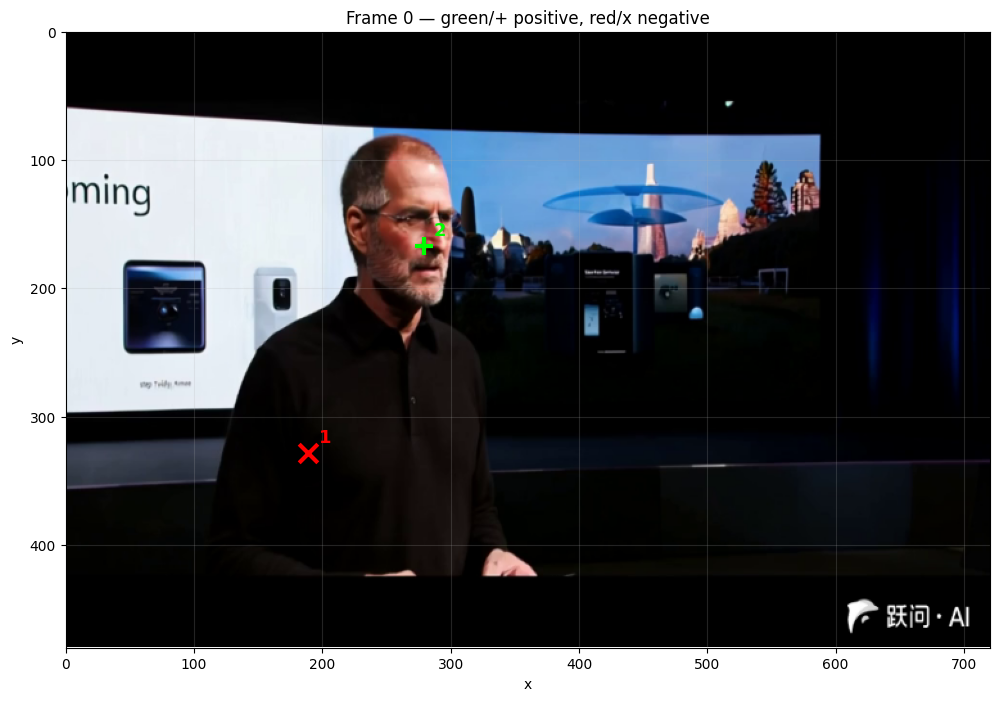

In [12]:
# 6. Verify click positions before loading SAM2
def show_clicks(frame, clicks, title="Manual SAM2 prompts"):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(frame)
    for number, (x, y, label) in enumerate(clicks, start=1):
        color = "lime" if label == 1 else "red"
        marker = "+" if label == 1 else "x"
        ax.scatter([x], [y], c=color, marker=marker, s=180, linewidths=3)
        ax.text(x + 8, y - 8, str(number), color=color, fontsize=13, weight="bold")
    ax.set_title(f"{title} — green/+ positive, red/x negative")
    ax.set_xlim(0, frame.shape[1])
    ax.set_ylim(frame.shape[0], 0)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.2)
    plt.show()


show_clicks(frames[PROMPT_FRAME], CLICKS, f"Frame {PROMPT_FRAME}")

## Fast restart from a saved SAM2 cache

After restarting the kernel, run cells 1–6 (imports, configuration, validation, video preprocessing, and click preview), then run the cache-loading cell below. If it succeeds, **skip the SAM2 load/segment/track/release cells** and continue at **Prepare PIL images and masks**. Text captions may be changed without invalidating the SAM2 cache.


In [13]:
# 6b. Restore propagated SAM2 masks after a kernel restart
SAM2_CACHE_LOADED = False
if LOAD_SAM2_CACHE:
    try:
        tracked_masks = load_sam2_cache()
        SAM2_CACHE_LOADED = True
        cached_mask_counts = tracked_masks[..., 0].sum(axis=(1, 2))
        first_cached_frame = int(np.flatnonzero(cached_mask_counts)[0])
        cached_overlay = frames[first_cached_frame].copy()
        cached_region = tracked_masks[first_cached_frame, ..., 0].astype(bool)
        cached_color = np.zeros_like(cached_overlay)
        cached_color[..., 1:] = 255
        cached_overlay[cached_region] = (
            0.5 * cached_overlay[cached_region] + 0.5 * cached_color[cached_region]
        ).astype(np.uint8)
        plt.figure(figsize=(12, 7))
        plt.imshow(cached_overlay)
        plt.title(f"Restored SAM2 mask overlay — frame {first_cached_frame}")
        plt.axis("off")
        plt.show()
        print("Cache is ready. Skip the SAM2 cells and continue at 'Prepare PIL images and masks'.")
    except (FileNotFoundError, ValueError, KeyError) as exc:
        print(f"No reusable SAM2 cache loaded: {exc}")
        print("Continue with the SAM2 loading, segmentation, and tracking cells below.")
else:
    print("SAM2 cache loading is disabled; continue with the SAM2 cells below.")


No reusable SAM2 cache loaded: SAM2 cache not found: /workspace/VideoPainter/app/notebook_outputs/yuewen_jobs_sam2_masks.npz
Continue with the SAM2 loading, segmentation, and tracking cells below.


In [14]:
# 7. Load SAM2 and initialize its video state
from sam2.build_sam import build_sam2_video_predictor

cuda_memory_report("before SAM2 load")
try:
    predictor = build_sam2_video_predictor(SAM2_MODEL_CONFIG, str(SAM2_CHECKPOINT))
    inference_state = predictor.init_state(
        images=frames,
        offload_video_to_cpu=SAM2_OFFLOAD_VIDEO_TO_CPU,
        offload_state_to_cpu=SAM2_OFFLOAD_STATE_TO_CPU,
        async_loading_frames=True,
    )
except torch.cuda.OutOfMemoryError as exc:
    cleanup_cuda()
    raise RuntimeError(
        "CUDA ran out of memory while loading SAM2. Restart the kernel or run the cleanup cell, "
        "then ensure SAM2 CPU offloading is enabled."
    ) from exc

print("SAM2 video state initialized.")
cuda_memory_report("after SAM2 load")

CUDA memory before SAM2 load: allocated=0.00 GiB, reserved=0.00 GiB, free=46.97 GiB, total=47.37 GiB
self.image_size 1024
Time taken to warm up the visual backbone and cache the image feature on frame 0: 1.10s
SAM2 video state initialized.
CUDA memory after SAM2 load: allocated=0.96 GiB, reserved=2.71 GiB, free=44.19 GiB, total=47.37 GiB


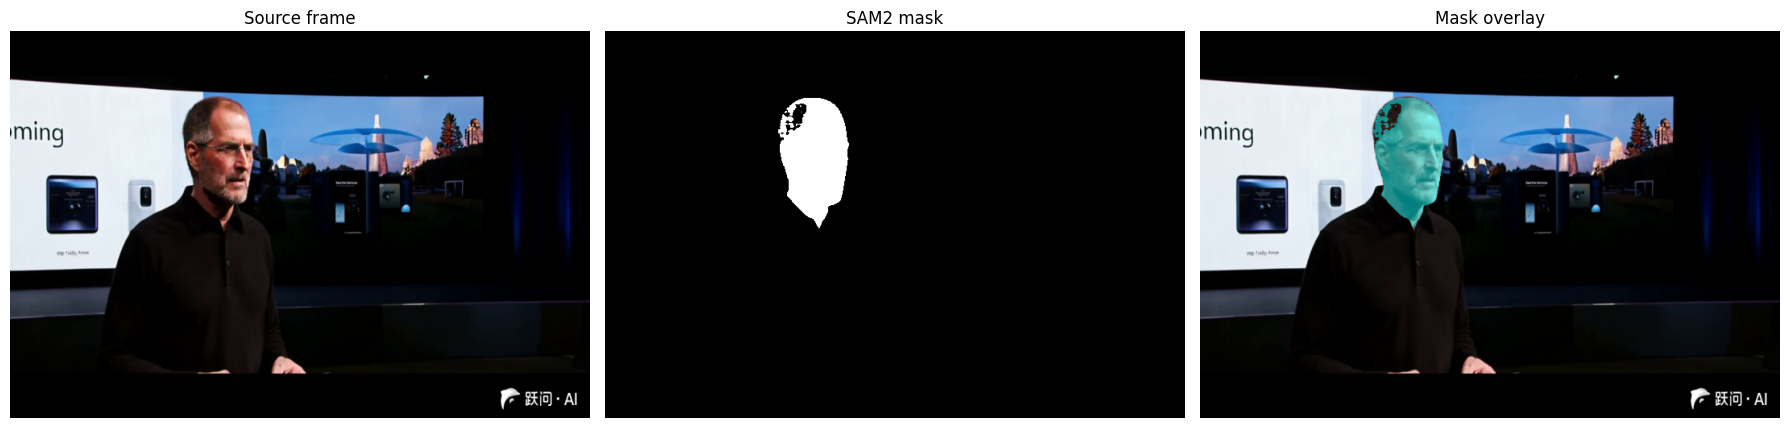

Mask pixels: 9,783; object IDs: [0]


In [15]:
# 8. Segment the selected frame
points = np.asarray([(x, y) for x, y, _ in CLICKS], dtype=np.float32)
labels = np.asarray([label for _, _, label in CLICKS], dtype=np.int32)

try:
    _, object_ids, mask_logits = predictor.add_new_points(
        inference_state=inference_state,
        frame_idx=PROMPT_FRAME,
        obj_id=0,
        points=points,
        labels=labels,
    )
except torch.cuda.OutOfMemoryError as exc:
    cleanup_cuda()
    raise RuntimeError("CUDA ran out of memory during SAM2 segmentation.") from exc

prompt_mask = (mask_logits[0].detach().float().cpu().squeeze().numpy() > 0).astype(np.uint8)
prompt_mask = cv2.resize(prompt_mask, (FRAME_WIDTH, FRAME_HEIGHT), interpolation=cv2.INTER_NEAREST)
if not prompt_mask.any():
    raise ValueError("SAM2 produced an empty mask. Adjust the positive/negative clicks and rerun this cell.")

overlay = frames[PROMPT_FRAME].copy()
cyan = np.zeros_like(overlay)
cyan[..., 1:] = 255
overlay[prompt_mask > 0] = (0.5 * overlay[prompt_mask > 0] + 0.5 * cyan[prompt_mask > 0]).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(frames[PROMPT_FRAME]); axes[0].set_title("Source frame")
axes[1].imshow(prompt_mask, cmap="gray"); axes[1].set_title("SAM2 mask")
axes[2].imshow(overlay); axes[2].set_title("Mask overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Mask pixels: {int(prompt_mask.sum()):,}; object IDs: {list(object_ids)}")

In [16]:
# 9. Propagate the mask and export a tracking preview
def write_video(video_frames, output_path, fps=8):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    writer = imageio.get_writer(str(output_path), fps=fps, codec="libx264")
    try:
        for frame in np.asarray(video_frames, dtype=np.uint8):
            writer.append_data(frame)
    finally:
        writer.close()
    if not output_path.is_file() or output_path.stat().st_size == 0:
        raise RuntimeError(f"Video export failed: {output_path}")
    return output_path


tracked_masks = np.zeros((len(frames), FRAME_HEIGHT, FRAME_WIDTH, 1), dtype=np.uint8)
try:
    for frame_index, _, output_logits in predictor.propagate_in_video(inference_state):
        combined = np.zeros(output_logits.shape[-2:], dtype=np.uint8)
        for object_logits in output_logits:
            combined |= (object_logits.detach().float().cpu().squeeze().numpy() > 0).astype(np.uint8)
        combined = cv2.resize(combined, (FRAME_WIDTH, FRAME_HEIGHT), interpolation=cv2.INTER_NEAREST)
        combined = scipy.ndimage.binary_dilation(combined, iterations=6).astype(np.uint8)
        if TRACK_START_FRAME <= frame_index <= TRACK_END_FRAME:
            tracked_masks[frame_index, ..., 0] = combined
except torch.cuda.OutOfMemoryError as exc:
    cleanup_cuda()
    raise RuntimeError("CUDA ran out of memory during SAM2 tracking.") from exc

if not tracked_masks[TRACK_START_FRAME:TRACK_END_FRAME + 1].any():
    raise ValueError("Tracking produced no masks in the requested frame range.")

tracking_preview = frames.copy()
mask_bool = tracked_masks[..., 0].astype(bool)
tracking_color = np.zeros_like(tracking_preview)
tracking_color[..., 1:] = 255
tracking_preview[mask_bool] = (
    0.5 * tracking_preview[mask_bool] + 0.5 * tracking_color[mask_bool]
).astype(np.uint8)

TRACKING_VIDEO_PATH = write_video(
    tracking_preview, OUTPUT_DIR / f"{Path(VIDEO_PATH).stem}_tracking.mp4", TARGET_FPS
)
print(f"Tracking preview: {TRACKING_VIDEO_PATH}")
display(Video(str(TRACKING_VIDEO_PATH), embed=True, width=720))
if SAVE_SAM2_CACHE:
    SAM2_CACHE_FILE = save_sam2_cache(tracked_masks)


propagate in video: 100%|██████████| 49/49 [01:03<00:00,  1.31s/it]


Tracking preview: /workspace/VideoPainter/app/notebook_outputs/yuewen_jobs_tracking.mp4


Saved SAM2 mask cache: /workspace/VideoPainter/app/notebook_outputs/yuewen_jobs_sam2_masks.npz


## Release SAM2 before loading VideoPainter

This is intentionally a separate step. Rerun the SAM2 loading cell if you later change the clicks.

In [17]:
# 10. Move SAM2 to CPU and release its cached state
try:
    predictor.reset_state(inference_state)
except Exception as exc:
    print(f"SAM2 state reset warning: {exc}")

try:
    predictor.to("cpu")
except (AttributeError, RuntimeError) as exc:
    print(f"SAM2 CPU move warning: {exc}")

del inference_state
del predictor
cleanup_cuda()
cuda_memory_report("after releasing SAM2")

CUDA memory after releasing SAM2: allocated=0.01 GiB, reserved=0.08 GiB, free=46.82 GiB, total=47.37 GiB


In [19]:
# 11. Prepare PIL images and masks for the existing app inference function
validation_images = [Image.fromarray(frame).convert("RGB") for frame in frames]
validation_masks = []
for mask in tracked_masks[..., 0]:
    mask_255 = (mask > 0).astype(np.uint8) * 255
    validation_masks.append(Image.fromarray(np.repeat(mask_255[..., None], 3, axis=-1)).convert("RGB"))

if len(validation_images) != len(validation_masks) or not validation_images:
    raise ValueError("Prepared images and masks must be non-empty and have equal lengths.")
if not any(np.asarray(mask).any() for mask in validation_masks):
    raise ValueError("All prepared masks are empty; rerun segmentation/tracking with different clicks.")

print(f"Prepared {len(validation_images)} images and {len(validation_masks)} masks.")

Prepared 49 images and 49 masks.


## Stage 1: FLUX first-frame inpainting

FLUX is loaded and run by itself. Its generated first frame is saved to disk so the model can be completely released before VideoPainter is loaded.

In [20]:
# 12. Restore the FLUX cache, or load FLUX only when the cache is unavailable
import importlib
import utils as videopainter_utils

# Reload local helpers so notebook reruns pick up offloading fixes without a kernel restart.
videopainter_utils = importlib.reload(videopainter_utils)
generate_flux_frame = videopainter_utils.generate_flux_frame
generate_video_frames = videopainter_utils.generate_video_frames
load_flux_model = videopainter_utils.load_flux_model
load_video_model = videopainter_utils.load_video_model

VIDEO_DEVICE = "cuda"
FLUX_DEVICE = "cuda"
VIDEO_DTYPE = torch.float16
FLUX_DTYPE = torch.float16
# Keep FLUX on GPU for first-frame generation, then release it before loading VideoPainter.
# VideoPainter can still use offloading after FLUX has been released.
VIDEO_OFFLOAD_MODE = "sequential"
FLUX_OFFLOAD_MODE = None

for name, selected_device in {
    "VIDEO_DEVICE": VIDEO_DEVICE,
    "FLUX_DEVICE": FLUX_DEVICE,
}.items():
    if selected_device not in {"cpu", "cuda"}:
        raise ValueError(f'{name} must be either "cpu" or "cuda".')
    if selected_device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError(f'{name}="cuda" was selected, but CUDA is unavailable.')

video_stem = Path(VIDEO_PATH).stem
FLUX_OUTPUT_PATH = Path(FLUX_FRAME_CACHE_PATH) if FLUX_FRAME_CACHE_PATH else OUTPUT_DIR / f"{video_stem}_flux_first_frame.png"
FLUX_MASKS_PATH = Path(FLUX_MASKS_CACHE_PATH) if FLUX_MASKS_CACHE_PATH else OUTPUT_DIR / f"{video_stem}_flux_masks.npz"
FLUX_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
FLUX_MASKS_PATH.parent.mkdir(parents=True, exist_ok=True)

actual_seed = int(SEED) if int(SEED) >= 0 else int(np.random.randint(0, 2**32 - 1))
flux_cache_hit = False

if LOAD_FLUX_CACHE and FLUX_OUTPUT_PATH.is_file() and FLUX_MASKS_PATH.is_file():
    try:
        with np.load(FLUX_MASKS_PATH, allow_pickle=False) as cached:
            cached_masks = cached["masks"]
            cached_seed = int(cached["seed"].item())
            cache_matches = (
                str(cached["video_path"].item()) == str(Path(VIDEO_PATH).resolve())
                and int(cached["video_size"].item()) == Path(VIDEO_PATH).stat().st_size
                and int(cached["video_mtime_ns"].item()) == Path(VIDEO_PATH).stat().st_mtime_ns
                and str(cached["prompt"].item()) == TARGET_REGION_CAPTION.strip()
                and int(cached["dilate_size"].item()) == int(DILATE_SIZE)
                and str(cached["inference_dtype"].item()) == str(FLUX_DTYPE)
                and cached_masks.shape[0] == len(validation_images)
                and (int(SEED) < 0 or cached_seed == int(SEED))
            )
            if cache_matches:
                with Image.open(FLUX_OUTPUT_PATH) as cached_frame:
                    flux_first_frame = cached_frame.convert("RGB").copy()
                video_masks = [Image.fromarray(mask).convert("RGB") for mask in cached_masks]
                actual_seed = cached_seed
                flux_cache_hit = True
                print(f"Loaded cached FLUX frame: {FLUX_OUTPUT_PATH}")
                print(f"Loaded cached FLUX masks: {FLUX_MASKS_PATH}")
            else:
                print("FLUX cache metadata does not match the current input/settings; regenerating it.")
    except (KeyError, OSError, ValueError) as exc:
        print(f"FLUX cache could not be loaded ({exc}); regenerating it.")

if not flux_cache_hit:
    print(f"Loading FLUX on {FLUX_DEVICE} with {FLUX_DTYPE}...")
    flux_pipeline = load_flux_model(
        img_inpainting_model=str(IMAGE_INPAINTING_MODEL_PATH),
        device=FLUX_DEVICE,
        dtype=FLUX_DTYPE,
        cpu_offload=False,
        offload_mode=FLUX_OFFLOAD_MODE,
    )
    print("FLUX loaded.")
else:
    print("Skipping FLUX model loading because a valid cache was found.")

Loading FLUX on cuda with torch.float16...


Loading pipeline components...: 100%|██████████| 7/7 [00:27<00:00,  3.99s/it]


FLUX loaded.


Dilating the mask with size 16...
Image inpainting prompt: Blood on face


  6%|▌         | 3/50 [00:00<00:10,  4.63it/s]

100%|██████████| 50/50 [00:11<00:00,  4.32it/s]
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an 

Image inpainting done! (480, 720, 3)
Saved FLUX frame cache: /workspace/VideoPainter/app/notebook_outputs/yuewen_jobs_flux_first_frame.png
Saved FLUX masks cache: /workspace/VideoPainter/app/notebook_outputs/yuewen_jobs_flux_masks.npz


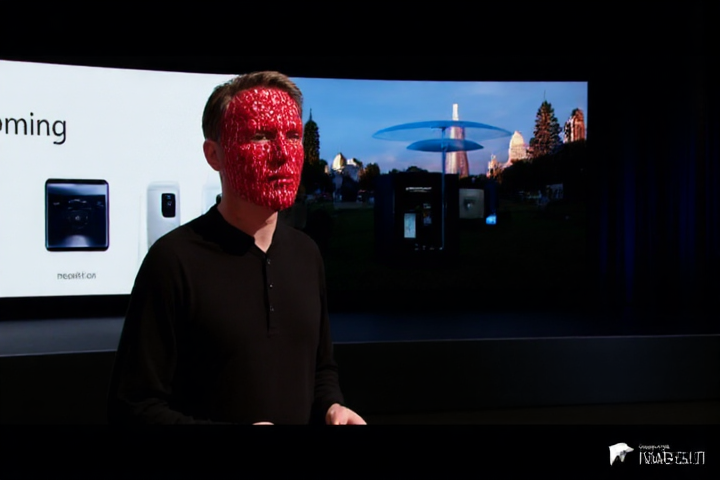

In [21]:
# 13. Run and cache FLUX only when needed
if not flux_cache_hit:
    flux_first_frame, video_masks = generate_flux_frame(
        images=validation_images,
        masks=validation_masks,
        pipe_img_inpainting=flux_pipeline,
        image_inpainting_prompt=TARGET_REGION_CAPTION.strip(),
        seed=actual_seed,
        dilate_size=int(DILATE_SIZE),
        inference_device=FLUX_DEVICE,
    )

    if SAVE_FLUX_CACHE:
        flux_first_frame.save(FLUX_OUTPUT_PATH)
        mask_array = np.stack([np.asarray(mask, dtype=np.uint8) for mask in video_masks])
        np.savez_compressed(
            FLUX_MASKS_PATH,
            masks=mask_array,
            seed=np.int64(actual_seed),
            video_path=str(Path(VIDEO_PATH).resolve()),
            video_size=np.int64(Path(VIDEO_PATH).stat().st_size),
            video_mtime_ns=np.int64(Path(VIDEO_PATH).stat().st_mtime_ns),
            prompt=TARGET_REGION_CAPTION.strip(),
            dilate_size=np.int64(DILATE_SIZE),
            inference_dtype=str(FLUX_DTYPE),
        )
        print(f"Saved FLUX frame cache: {FLUX_OUTPUT_PATH}")
        print(f"Saved FLUX masks cache: {FLUX_MASKS_PATH}")
else:
    print("Using the cached FLUX outputs.")

display(flux_first_frame)

In [22]:
# 14. Fully release FLUX before loading VideoPainter
release_model("flux_pipeline")
cuda_memory_report("after releasing FLUX")
print("FLUX released (or was skipped because cached outputs were loaded).")

CUDA memory after releasing FLUX: allocated=0.01 GiB, reserved=0.08 GiB, free=46.81 GiB, total=47.37 GiB
FLUX released (or was skipped because cached outputs were loaded).


## Stage 2: VideoPainter video generation

Only after FLUX has been released is VideoPainter loaded. The saved FLUX image becomes VideoPainter’s first frame.

In [23]:
# 15. Load VideoPainter only when generated frame cache is unavailable
import json
SAVE_VIDEO_FRAME_CACHE = globals().get("SAVE_VIDEO_FRAME_CACHE", True)
LOAD_VIDEO_FRAME_CACHE = globals().get("LOAD_VIDEO_FRAME_CACHE", True)
VIDEO_FRAME_CACHE_PATH = globals().get("VIDEO_FRAME_CACHE_PATH", None)
video_stem = globals().get("video_stem", Path(VIDEO_PATH).stem)
VIDEO_FRAME_CACHE_DIR = Path(VIDEO_FRAME_CACHE_PATH) if VIDEO_FRAME_CACHE_PATH else OUTPUT_DIR / f"{video_stem}_videopainter_frames"
VIDEO_FRAME_CACHE_METADATA_PATH = VIDEO_FRAME_CACHE_DIR / "metadata.json"
EXPECTED_VIDEO_FRAME_COUNT = max(len(validation_images) - 1, 0)

def _file_metadata(path):
    path = Path(path)
    if not path.is_file():
        return None
    stat = path.stat()
    return {
        "path": str(path.resolve()),
        "size": int(stat.st_size),
        "mtime_ns": int(stat.st_mtime_ns),
    }


def _video_frame_cache_files():
    return [VIDEO_FRAME_CACHE_DIR / f"frame_{index:04d}.png" for index in range(EXPECTED_VIDEO_FRAME_COUNT)]


def _video_frame_cache_metadata():
    return {
        "video_path": str(Path(VIDEO_PATH).resolve()),
        "video_size": int(Path(VIDEO_PATH).stat().st_size),
        "video_mtime_ns": int(Path(VIDEO_PATH).stat().st_mtime_ns),
        "prompt": VIDEO_CAPTION.strip(),
        "seed": int(actual_seed),
        "cfg_scale": float(CFG_SCALE),
        "inference_dtype": str(VIDEO_DTYPE),
        "video_model_path": str(Path(VIDEO_MODEL_PATH).resolve()),
        "inpainting_branch_path": str(Path(INPAINTING_BRANCH_PATH).resolve()),
        "id_adapter_path": str(Path(ID_ADAPTER_PATH).resolve()),
        "frame_count": int(EXPECTED_VIDEO_FRAME_COUNT),
        "frame_width": int(FRAME_WIDTH),
        "frame_height": int(FRAME_HEIGHT),
        "flux_output": _file_metadata(FLUX_OUTPUT_PATH),
    }


def _load_video_frame_cache():
    if not LOAD_VIDEO_FRAME_CACHE:
        return None
    if EXPECTED_VIDEO_FRAME_COUNT <= 0:
        return None
    if not VIDEO_FRAME_CACHE_METADATA_PATH.is_file():
        print("VideoPainter frame cache metadata was not found; generating frames.")
        return None
    frame_files = _video_frame_cache_files()
    missing_frames = [path for path in frame_files if not path.is_file()]
    if missing_frames:
        print(f"VideoPainter frame cache is incomplete ({len(missing_frames)} missing); generating frames.")
        return None
    try:
        cached_metadata = json.loads(VIDEO_FRAME_CACHE_METADATA_PATH.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError) as exc:
        print(f"VideoPainter frame cache metadata could not be loaded ({exc}); generating frames.")
        return None
    expected_metadata = _video_frame_cache_metadata()
    if cached_metadata != expected_metadata:
        print("VideoPainter frame cache metadata does not match the current input/settings; generating frames.")
        return None
    frames = []
    try:
        for frame_path in frame_files:
            with Image.open(frame_path) as frame:
                frames.append(np.asarray(frame.convert("RGB"), dtype=np.uint8))
    except (OSError, ValueError) as exc:
        print(f"VideoPainter frame cache could not be loaded ({exc}); generating frames.")
        return None
    print(f"Loaded {len(frames)} cached VideoPainter frames from: {VIDEO_FRAME_CACHE_DIR}")
    return np.stack(frames)


def _save_video_frame_cache(frames):
    if not SAVE_VIDEO_FRAME_CACHE:
        return
    frames = np.asarray(frames, dtype=np.uint8)
    if frames.shape[0] != EXPECTED_VIDEO_FRAME_COUNT:
        print(
            f"Skipping VideoPainter frame cache metadata save: expected {EXPECTED_VIDEO_FRAME_COUNT} frames, "
            f"got {frames.shape[0]}."
        )
        return
    missing_frames = [path for path in _video_frame_cache_files() if not path.is_file()]
    if missing_frames:
        print(
            f"Skipping VideoPainter frame cache metadata save: {len(missing_frames)} frame files were not written."
        )
        return
    VIDEO_FRAME_CACHE_METADATA_PATH.write_text(
        json.dumps(_video_frame_cache_metadata(), indent=2, sort_keys=True),
        encoding="utf-8",
    )
    print(f"Saved VideoPainter frame cache metadata: {VIDEO_FRAME_CACHE_METADATA_PATH}")


generated = _load_video_frame_cache()
video_frame_cache_hit = generated is not None

if video_frame_cache_hit:
    if "validation_pipeline" in globals() and "release_model" in globals():
        release_model("validation_pipeline")
    print("Skipping VideoPainter model loading because cached frames were found.")
else:
    print(f"Loading VideoPainter on {VIDEO_DEVICE} with {VIDEO_DTYPE}...")
    try:
        validation_pipeline = load_video_model(
            model_path=str(VIDEO_MODEL_PATH),
            inpainting_branch=str(INPAINTING_BRANCH_PATH),
            id_adapter=str(ID_ADAPTER_PATH),
            device=VIDEO_DEVICE,
            dtype=VIDEO_DTYPE,
            cpu_offload=False,
            offload_mode=VIDEO_OFFLOAD_MODE,
        )
    except RuntimeError as exc:
        raise RuntimeError(
            f"VideoPainter could not be loaded on {VIDEO_DEVICE} with {VIDEO_DTYPE}. "
            "Check available GPU VRAM or system RAM."
        ) from exc
    print("VideoPainter loaded.")


VideoPainter frame cache metadata was not found; generating frames.
Loading VideoPainter on cuda with torch.float16...


Loading pipeline components...: 100%|██████████| 5/5 [00:09<00:00,  1.84s/it]


list_adapters_component_wise: {'transformer': ['test_1']}
Enabling sequential CPU offloading for VideoPainter pipeline...
VideoPainter loaded.


In [24]:
# 16. Run VideoPainter with the saved FLUX first frame, cache frames, and export the result
if not video_frame_cache_hit:
    video_images = [image.copy() for image in validation_images]
    if FLUX_OUTPUT_PATH.is_file():
        with Image.open(FLUX_OUTPUT_PATH) as saved_flux_frame:
            video_images[0] = saved_flux_frame.convert("RGB").copy()
    else:
        video_images[0] = flux_first_frame.convert("RGB").copy()

    try:
        generated = generate_video_frames(
            images=video_images,
            masks=video_masks,
            pipe=validation_pipeline,
            prompt=VIDEO_CAPTION.strip(),
            seed=actual_seed,
            cfg_scale=float(CFG_SCALE),
            frame_output_dir=VIDEO_FRAME_CACHE_DIR if SAVE_VIDEO_FRAME_CACHE else None,
        )
    except torch.cuda.OutOfMemoryError as exc:
        release_model("validation_pipeline")
        raise RuntimeError(
            "CUDA ran out of memory during VideoPainter inference. Release other GPU processes "
            "or enable VideoPainter CPU offloading before retrying."
        ) from exc
else:
    print("Using cached VideoPainter frames.")

generated = np.asarray(generated)
if generated.size == 0:
    raise RuntimeError("VideoPainter returned no frames.")
if np.issubdtype(generated.dtype, np.floating):
    generated = np.clip(generated * 255.0, 0, 255).astype(np.uint8)
else:
    generated = np.clip(generated, 0, 255).astype(np.uint8)

if not video_frame_cache_hit:
    _save_video_frame_cache(generated)

if "write_video" not in globals():
    def write_video(video_frames, output_path, fps=8):
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        writer = imageio.get_writer(str(output_path), fps=fps, codec="libx264")
        try:
            for frame in np.asarray(video_frames, dtype=np.uint8):
                writer.append_data(frame)
        finally:
            writer.close()
        if not output_path.is_file() or output_path.stat().st_size == 0:
            raise RuntimeError(f"Video export failed: {output_path}")
        return output_path

OUTPUT_VIDEO_PATH = write_video(
    generated, OUTPUT_DIR / f"{Path(VIDEO_PATH).stem}_inpainted.mp4", TARGET_FPS
)
print(f"Seed: {actual_seed}")
print(f"Generated video: {OUTPUT_VIDEO_PATH}")
cuda_memory_report("after inference")
display(Video(str(OUTPUT_VIDEO_PATH), embed=True, width=720))


100%|██████████| 50/50 [13:23<00:00, 16.08s/it]


Saved 48 VideoPainter frames to: /workspace/VideoPainter/app/notebook_outputs/yuewen_jobs_videopainter_frames
Video inpainting done! (48, 480, 720, 3), 0.0, 1.0
Saved VideoPainter frame cache metadata: /workspace/VideoPainter/app/notebook_outputs/yuewen_jobs_videopainter_frames/metadata.json
Seed: 42
Generated video: /workspace/VideoPainter/app/notebook_outputs/yuewen_jobs_inpainted.mp4
CUDA memory after inference: allocated=0.21 GiB, reserved=0.29 GiB, free=46.60 GiB, total=47.37 GiB


## Optional final cleanup

Run this after saving the result, or before loading VideoPainter again with different settings.

In [ ]:
# 17. Optional final model cleanup
release_model("validation_pipeline")
cuda_memory_report("after final cleanup")